<a href="https://colab.research.google.com/github/hayajahan07/ACMRecruitment-hayajahan07/blob/main/questline-2/6-full-pipeline/solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


df = sns.load_dataset('titanic')
df.rename(columns={'survived':'Survived','sex':'Sex','age':'Age','embarked':'Embarked','fare':'Fare','pclass':'Pclass','sibsp':'SibSp','parch':'Parch','deck':'Deck'}, inplace=True)
print("Loaded titanic without any upload")
print(df.head())
print(df.isnull().sum())

Loaded titanic without any upload
   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male Deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
Survived         0
Pclass           0
Sex              0
Age            177
SibSp            0
Parch            0
Fare             0
Embarked         2
class            0
who           

/tmp/ipykernel_3660/1731704502.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_3660/1731704502.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

Train 712 Test 179 Ratio 0.38
Accuracy: 79.89%
[[97 13]
 [23 46]]
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       110
           1       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179



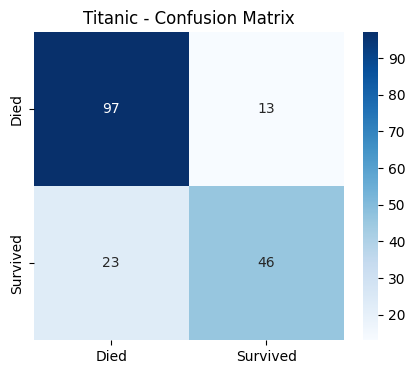

            feature  importance
1         num__Fare    0.217109
0          num__Age    0.214063
9     cat__Sex_male    0.133018
8   cat__Sex_female    0.130032
22    cat__Deck_nan    0.041435
2   num__FamilySize    0.038357
7     cat__Pclass_3    0.038167
5     cat__Pclass_1    0.026955
4        num__Parch    0.025307
3        num__SibSp    0.025150


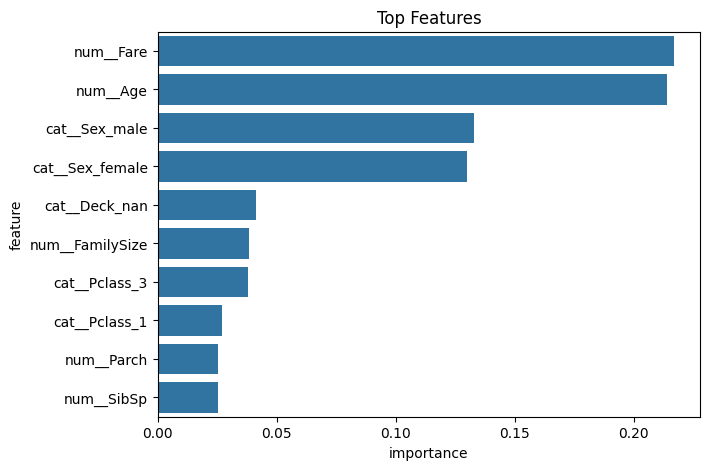

In [2]:
# --- 6a Restore ---
df['Deck'] = df['Deck'].astype(str)
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df['Deck'].fillna('Unknown', inplace=True)
df['Fare'].fillna(df['Fare'].median(), inplace=True)

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Deck']
target = 'Survived'
df_model = df[features + [target]].dropna()
X = df_model[features]
y = df_model[target]

numeric_features = ['Age', 'Fare', 'FamilySize', 'SibSp', 'Parch']
categorical_features = [f for f in features if f not in numeric_features]

numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer([('num', numeric_transformer, numeric_features), ('cat', categorical_transformer, categorical_features)])

# 6e Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train {X_train.shape[0]} Test {X_test.shape[0]} Ratio {y.mean():.2f}")

# 6f Train
clf = Pipeline([('preprocessor', preprocessor), ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))])
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print(f"Accuracy: {acc*100:.2f}%")
print(cm)
print(classification_report(y_test, y_pred))

# Plots
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Died','Survived'], yticklabels=['Died','Survived'])
plt.title('Titanic - Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()

import pandas as pd
feature_names = clf.named_steps['preprocessor'].get_feature_names_out()
importances = clf.named_steps['classifier'].feature_importances_
feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False)
print(feat_imp.head(10))
plt.figure(figsize=(7,5))
sns.barplot(data=feat_imp.head(10), x='importance', y='feature')
plt.title('Top Features')
plt.savefig('feature_importance.png')
plt.show()

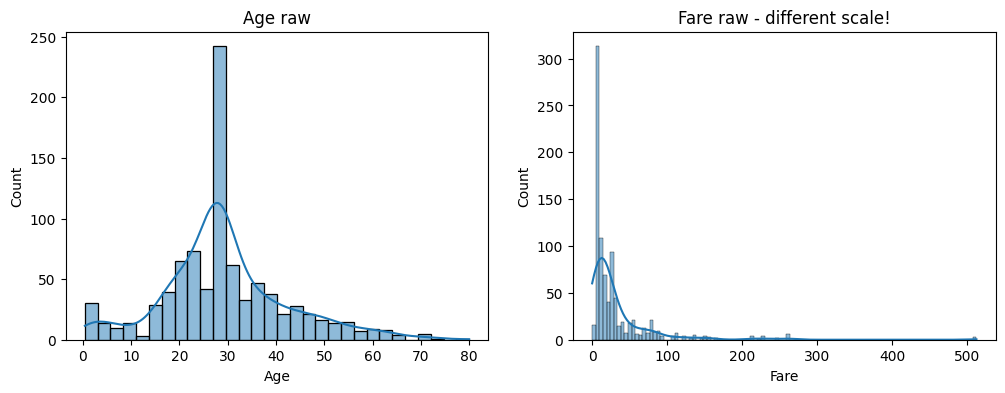

In [3]:
# Distribution plot for scaling justification
plt.figure(figsize=(12,4))
plt.subplot(1,2,1); sns.histplot(df['Age'], kde=True); plt.title('Age raw')
plt.subplot(1,2,2); sns.histplot(df['Fare'], kde=True); plt.title('Fare raw - different scale!')
plt.savefig('scale_justification.png'); plt.show()